# Method Comparison: Neural Fiber Reconstruction

Comparing four reconstruction methods:
- **Pure MST** (`output/pure`) — baseline classical MST
- **XGB MST** (`output/xgb_mst`) — XGBoost-guided MST
- **UNet** (`output/unet_eval`) — UNet-based reconstruction
- **Hierarchical** (`output/hierarchical`) — hierarchical approach

Metric: **Average Hausdorff Distance** (lower = better)

In [10]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path

# ── Load data ──────────────────────────────────────────────────────────────
METHODS = {
    "Pure MST":    "output/pure/results.json",
    "Hierarchical":"output/hierarchical/results.json",
    "XGB MST":     "output/xgb_mst/results.json",
    "UNet":        "output/unet_eval/results.json",
}

ROOT = Path("..")   # notebook is in notebooks/, data is one level up

data = {}
for name, path in METHODS.items():
    with open(ROOT / path) as f:
        data[name] = json.load(f)

# Build per-sample DataFrame
records = []
for method, d in data.items():
    for sid, s in d["samples"].items():
        records.append({
            "method": method,
            "sample": sid,
            "hausdorff": s["hausdorff_distance"],
            "hd_pred_to_gt": s["hausdorff_distance_pred_to_gt"],
            "hd_gt_to_pred": s["hausdorff_distance_gt_to_pred"],
            "nodes_pred": s["num_nodes_pred"],
            "nodes_gt": s["num_nodes_gt"],
            "edges_pred": s["num_edges_pred"],
            "edges_gt": s["num_edges_gt"],
            "components": s["num_components_pred"],
        })

df = pd.DataFrame(records)
samples = sorted(df["sample"].unique())
methods = list(METHODS.keys())

# Color palette
COLORS = {
    "Pure MST":    "#4C72B0",
    "XGB MST":     "#DD8452",
    "UNet":        "#55A868",
    "Hierarchical":"#C44E52",
}

print(f"Loaded {len(samples)} samples × {len(methods)} methods")
df.groupby("method")["hausdorff"].agg(["mean","median","std"]).round(3)

Loaded 17 samples × 4 methods


,mean,median,std
method,,,
Hierarchical,6.144,5.912,2.861
Pure MST,6.199,5.884,2.788
UNet,3.595,2.899,2.089
XGB MST,6.098,5.938,2.789


## 1. Summary Statistics — Mean / Median / Std

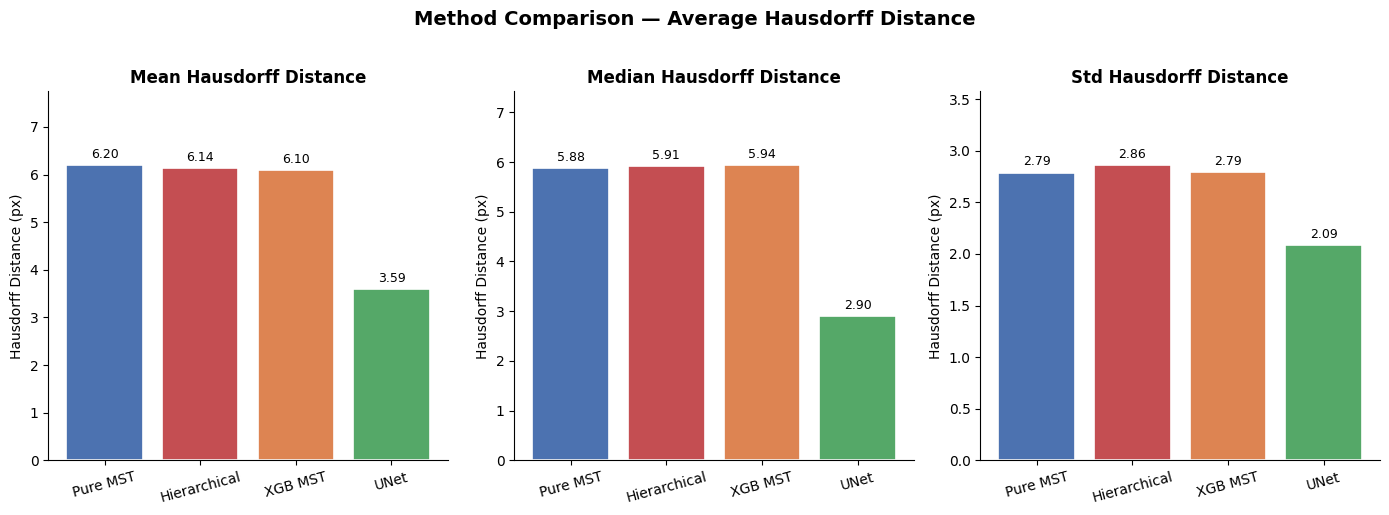

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
stats = ["mean", "median", "std"]
titles = ["Mean Hausdorff Distance", "Median Hausdorff Distance", "Std Hausdorff Distance"]

summary = df.groupby("method")["hausdorff"].agg(["mean", "median", "std"])

for ax, stat, title in zip(axes, stats, titles):
    vals = [summary.loc[m, stat] for m in methods]
    bars = ax.bar(methods, vals, color=[COLORS[m] for m in methods], edgecolor="white", linewidth=1.2)
    ax.bar_label(bars, fmt="%.2f", padding=3, fontsize=9)
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.set_ylabel("Hausdorff Distance (px)")
    ax.set_ylim(0, max(vals) * 1.25)
    ax.tick_params(axis="x", rotation=15)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.suptitle("Method Comparison — Average Hausdorff Distance", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

## 2. Box Plot — Distribution of Hausdorff Distances

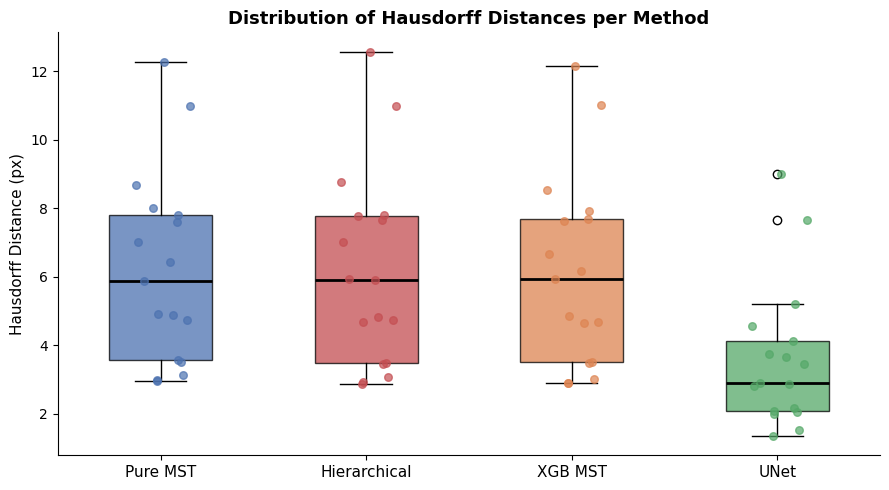

In [12]:
fig, ax = plt.subplots(figsize=(9, 5))

plot_data = [df[df["method"] == m]["hausdorff"].values for m in methods]
bp = ax.boxplot(plot_data, patch_artist=True, notch=False, widths=0.5,
                medianprops=dict(color="black", linewidth=2))

for patch, method in zip(bp["boxes"], methods):
    patch.set_facecolor(COLORS[method])
    patch.set_alpha(0.75)

# Overlay individual points
for i, (vals, method) in enumerate(zip(plot_data, methods), start=1):
    jitter = np.random.default_rng(42).uniform(-0.15, 0.15, len(vals))
    ax.scatter(i + jitter, vals, color=COLORS[method], s=30, alpha=0.7, zorder=3)

ax.set_xticks(range(1, len(methods) + 1))
ax.set_xticklabels(methods, fontsize=11)
ax.set_ylabel("Hausdorff Distance (px)", fontsize=11)
ax.set_title("Distribution of Hausdorff Distances per Method", fontsize=13, fontweight="bold")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()

## 3. Per-Sample Hausdorff Distance (Grouped Bar)

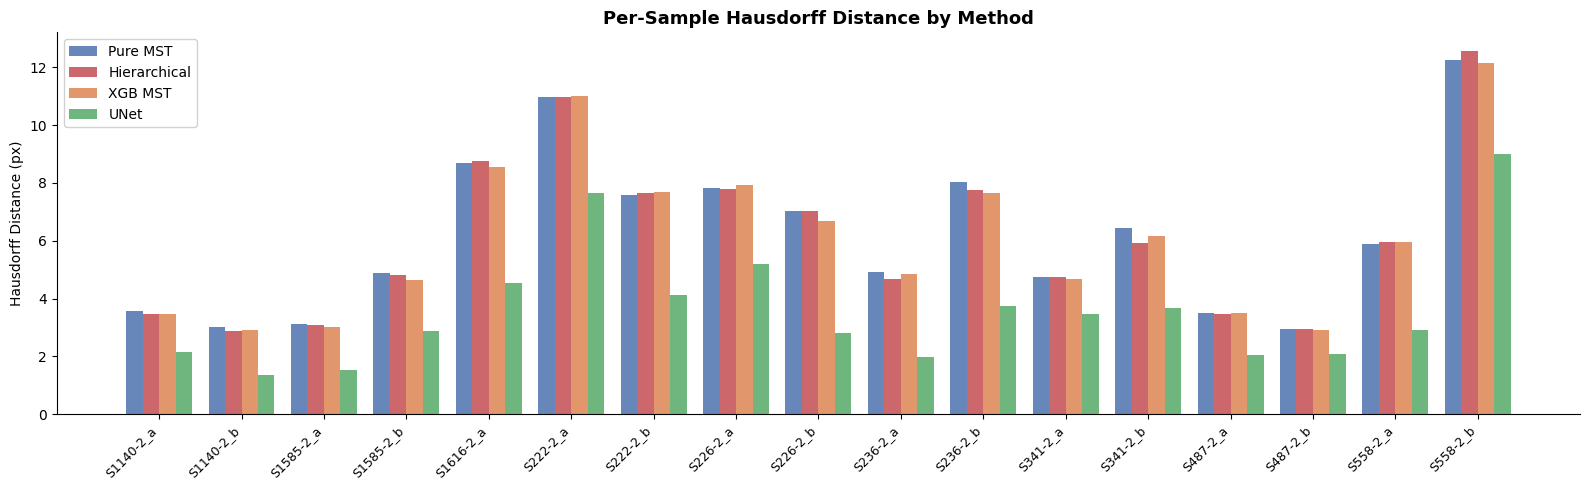

In [13]:
fig, ax = plt.subplots(figsize=(16, 5))

n_methods = len(methods)
n_samples = len(samples)
x = np.arange(n_samples)
width = 0.2

for i, method in enumerate(methods):
    subset = df[df["method"] == method].set_index("sample")
    vals = [subset.loc[s, "hausdorff"] for s in samples]
    offset = (i - n_methods / 2 + 0.5) * width
    ax.bar(x + offset, vals, width, label=method, color=COLORS[method], alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(samples, rotation=45, ha="right", fontsize=9)
ax.set_ylabel("Hausdorff Distance (px)")
ax.set_title("Per-Sample Hausdorff Distance by Method", fontsize=13, fontweight="bold")
ax.legend(loc="upper left", framealpha=0.9)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()

## 4. Per-Sample Line Chart — Easy to Spot Winners

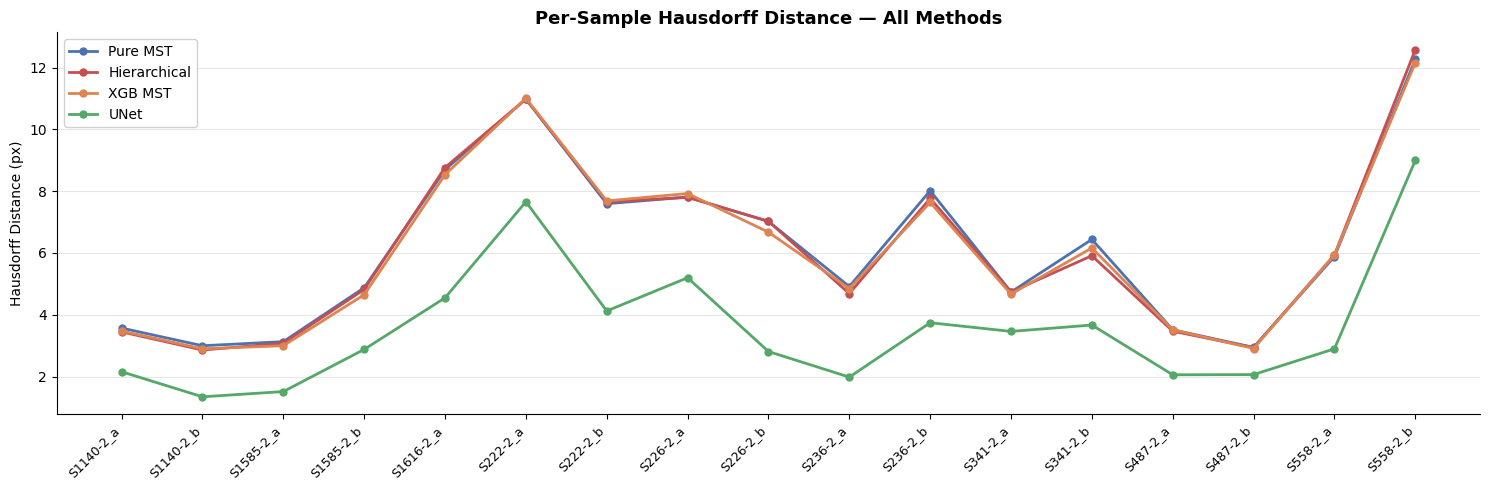

In [14]:
fig, ax = plt.subplots(figsize=(15, 5))

x = np.arange(len(samples))
for method in methods:
    subset = df[df["method"] == method].set_index("sample")
    vals = [subset.loc[s, "hausdorff"] for s in samples]
    ax.plot(x, vals, marker="o", label=method, color=COLORS[method], linewidth=2, markersize=5)

ax.set_xticks(x)
ax.set_xticklabels(samples, rotation=45, ha="right", fontsize=9)
ax.set_ylabel("Hausdorff Distance (px)")
ax.set_title("Per-Sample Hausdorff Distance — All Methods", fontsize=13, fontweight="bold")
ax.legend(framealpha=0.9)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Directional Hausdorff — Pred→GT vs GT→Pred

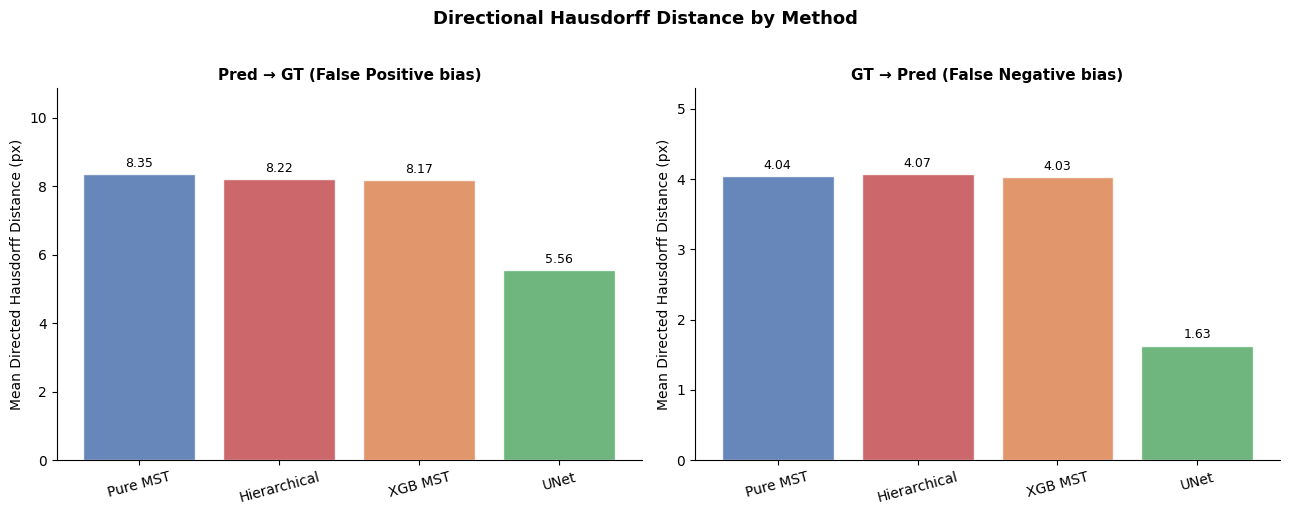

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=False)

for ax, col, direction in zip(
    axes,
    ["hd_pred_to_gt", "hd_gt_to_pred"],
    ["Pred → GT (False Positive bias)", "GT → Pred (False Negative bias)"]
):
    vals = [df[df["method"] == m][col].mean() for m in methods]
    bars = ax.bar(methods, vals, color=[COLORS[m] for m in methods], alpha=0.85, edgecolor="white")
    ax.bar_label(bars, fmt="%.2f", padding=3, fontsize=9)
    ax.set_title(direction, fontsize=11, fontweight="bold")
    ax.set_ylabel("Mean Directed Hausdorff Distance (px)")
    ax.set_ylim(0, max(vals) * 1.3)
    ax.tick_params(axis="x", rotation=15)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.suptitle("Directional Hausdorff Distance by Method", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

## 6. Graph Coverage — Predicted vs Ground Truth Nodes & Edges

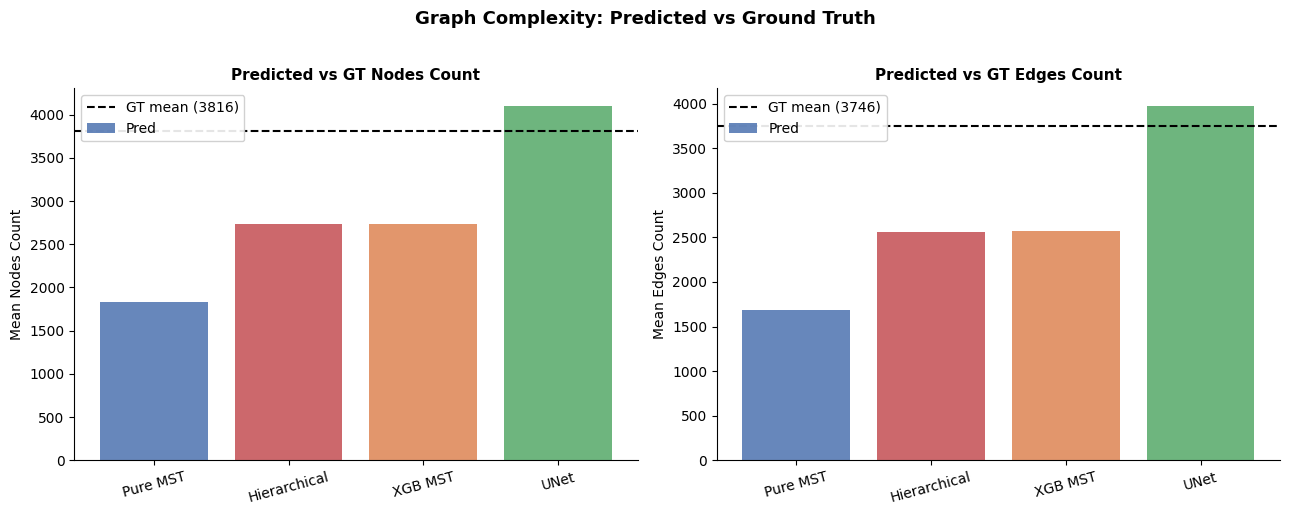

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, pred_col, gt_col, label in zip(
    axes,
    ["nodes_pred", "edges_pred"],
    ["nodes_gt", "edges_gt"],
    ["Nodes", "Edges"],
):
    gt_mean = df[df["method"] == methods[0]][gt_col].mean()  # GT is same for all
    pred_means = [df[df["method"] == m][pred_col].mean() for m in methods]

    x = np.arange(len(methods))
    ax.bar(x, pred_means, color=[COLORS[m] for m in methods], alpha=0.85, label="Pred")
    ax.axhline(gt_mean, color="black", linestyle="--", linewidth=1.5, label=f"GT mean ({gt_mean:.0f})")

    ax.set_xticks(x)
    ax.set_xticklabels(methods, rotation=15)
    ax.set_ylabel(f"Mean {label} Count")
    ax.set_title(f"Predicted vs GT {label} Count", fontsize=11, fontweight="bold")
    ax.legend(framealpha=0.9)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.suptitle("Graph Complexity: Predicted vs Ground Truth", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

## 7. Heatmap — Per-Sample Hausdorff Distance

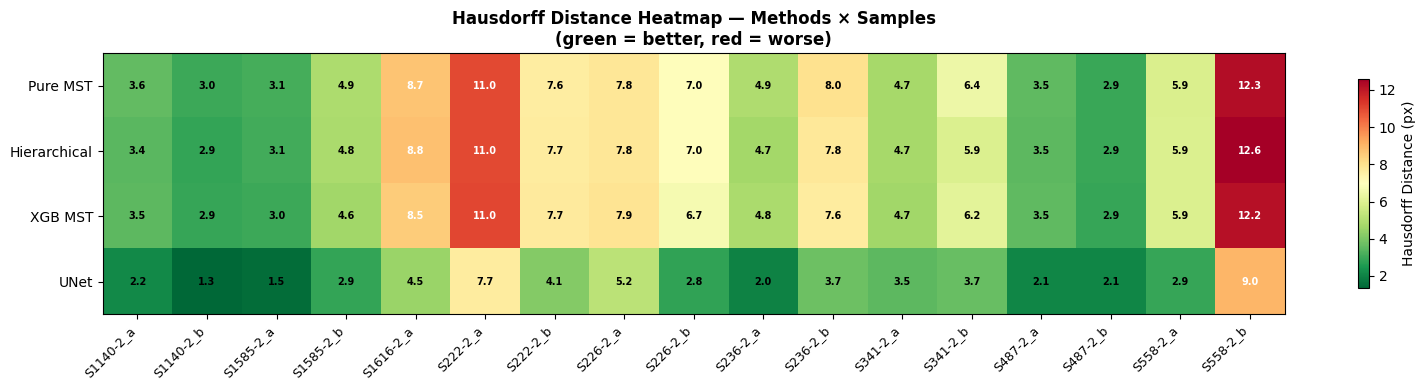

In [17]:
import matplotlib.colors as mcolors

# Build matrix: rows = methods, cols = samples
matrix = np.array([
    [df[(df["method"] == m) & (df["sample"] == s)]["hausdorff"].values[0]
     for s in samples]
    for m in methods
])

fig, ax = plt.subplots(figsize=(16, 4))
im = ax.imshow(matrix, aspect="auto", cmap="RdYlGn_r", vmin=matrix.min(), vmax=matrix.max())

ax.set_xticks(range(len(samples)))
ax.set_xticklabels(samples, rotation=45, ha="right", fontsize=9)
ax.set_yticks(range(len(methods)))
ax.set_yticklabels(methods, fontsize=10)

# Annotate cells
for i in range(len(methods)):
    for j in range(len(samples)):
        val = matrix[i, j]
        # Use white text on dark cells
        norm_val = (val - matrix.min()) / (matrix.max() - matrix.min())
        text_color = "white" if norm_val > 0.6 else "black"
        ax.text(j, i, f"{val:.1f}", ha="center", va="center",
                fontsize=7, color=text_color, fontweight="bold")

plt.colorbar(im, ax=ax, label="Hausdorff Distance (px)", shrink=0.8)
ax.set_title("Hausdorff Distance Heatmap — Methods × Samples\n(green = better, red = worse)",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

## 8. Rank Analysis — How Often Each Method Wins

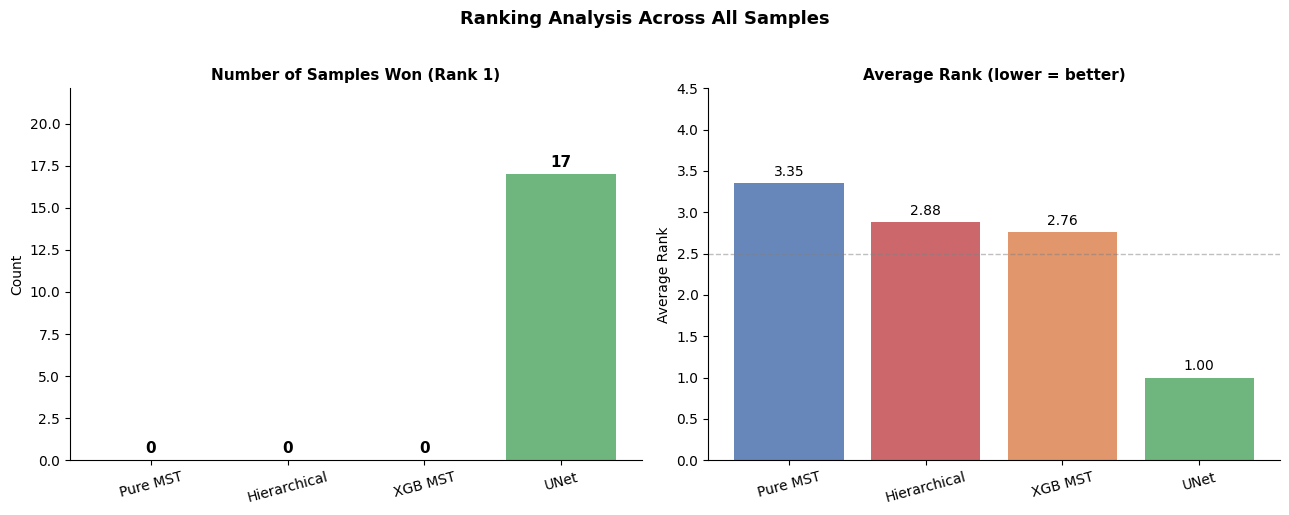


Full ranking summary:
UNet            1.000000
XGB MST         2.764706
Hierarchical    2.882353
Pure MST        3.352941


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Rank 1 wins ──
wins = {m: 0 for m in methods}
for s in samples:
    sample_vals = {m: df[(df["method"] == m) & (df["sample"] == s)]["hausdorff"].values[0]
                   for m in methods}
    winner = min(sample_vals, key=sample_vals.get)
    wins[winner] += 1

ax = axes[0]
bars = ax.bar(methods, [wins[m] for m in methods],
              color=[COLORS[m] for m in methods], alpha=0.85)
ax.bar_label(bars, padding=3, fontsize=11, fontweight="bold")
ax.set_title("Number of Samples Won (Rank 1)", fontsize=11, fontweight="bold")
ax.set_ylabel("Count")
ax.set_ylim(0, max(wins.values()) * 1.3)
ax.tick_params(axis="x", rotation=15)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# ── Average rank ──
ranks_df = pd.DataFrame({
    m: [df[(df["method"] == m) & (df["sample"] == s)]["hausdorff"].values[0]
        for s in samples]
    for m in methods
}, index=samples)
avg_ranks = ranks_df.rank(axis=1).mean()

ax = axes[1]
bars = ax.bar(methods, [avg_ranks[m] for m in methods],
              color=[COLORS[m] for m in methods], alpha=0.85)
ax.bar_label(bars, fmt="%.2f", padding=3, fontsize=10)
ax.set_title("Average Rank (lower = better)", fontsize=11, fontweight="bold")
ax.set_ylabel("Average Rank")
ax.set_ylim(0, len(methods) + 0.5)
ax.axhline(2.5, color="gray", linestyle="--", linewidth=1, alpha=0.5)
ax.tick_params(axis="x", rotation=15)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.suptitle("Ranking Analysis Across All Samples", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

print("\nFull ranking summary:")
print(avg_ranks.sort_values().to_string())